
# Exercise 5.1 : Chunksize


L=      10, P=1: pi≈3.141444, t=0.791s | P=2: pi≈3.141444, t=3.263s
L=     100, P=1: pi≈3.141772, t=0.232s | P=2: pi≈3.141772, t=0.631s
L=    1000, P=1: pi≈3.140956, t=0.198s | P=2: pi≈3.140956, t=0.199s
L=   10000, P=1: pi≈3.142064, t=0.199s | P=2: pi≈3.142064, t=0.133s
L=  100000, P=1: pi≈3.141896, t=0.195s | P=2: pi≈3.141896, t=0.114s
L= 1000000, P=1: pi≈3.139676, t=0.193s | P=2: pi≈3.139676, t=0.210s


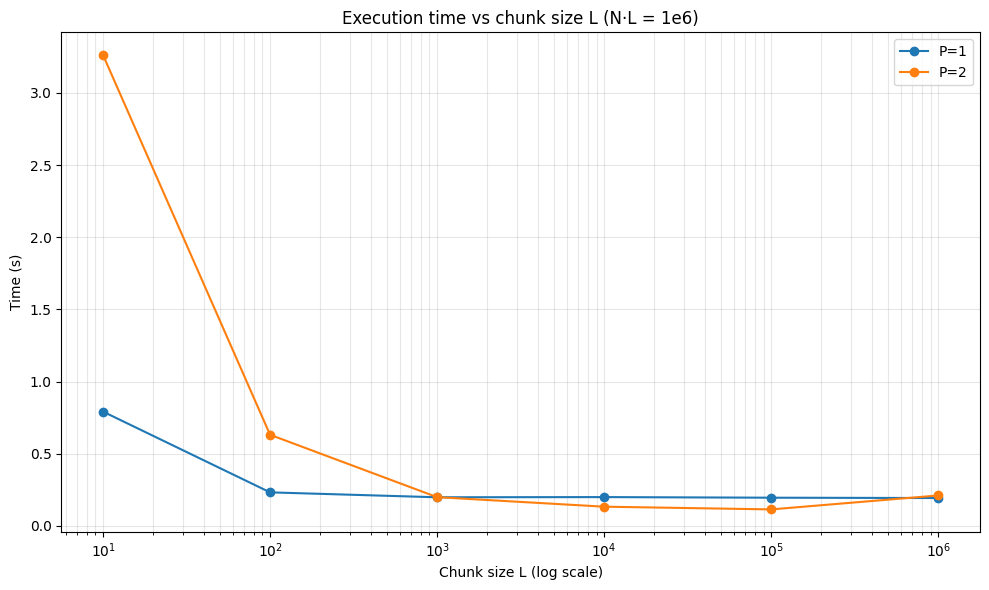

In [2]:
import multiprocessing as mp
import random, time
import matplotlib.pyplot as plt

TRIALS = 1_000_000

def count_inside(n, seed):
    random.seed(seed)
    c = 0
    for _ in range(n):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1.0:
            c += 1
    return c

def timed_run(L, P, base_seed=12345):
    N = TRIALS // L
    tasks = [(L, base_seed + i*97) for i in range(N)]
    if P == 1:
        t0 = time.perf_counter()
        s = sum(count_inside(L, base_seed + i*97) for i in range(N))
        dt = time.perf_counter() - t0
    else:
        t0 = time.perf_counter()
        with mp.Pool(P) as pool:
            s = sum(pool.starmap(count_inside, tasks, chunksize=1))
        dt = time.perf_counter() - t0
    pi = 4.0 * s / TRIALS
    return pi, dt

if __name__ == "__main__":
    Ls = [10, 100, 1_000, 10_000, 100_000, 1_000_000]
    P_single = 1
    P_multi = min(8, mp.cpu_count() or 8)

    ts_single, ts_multi = [], []
    pis_single, pis_multi = [], []

    for L in Ls:
        pi1, t1 = timed_run(L, P_single)
        pi8, t8 = timed_run(L, P_multi)
        pis_single.append(pi1); ts_single.append(t1)
        pis_multi.append(pi8);  ts_multi.append(t8)
        print(f"L={L:>8}, P={P_single}: pi≈{pi1:.6f}, t={t1:.3f}s | P={P_multi}: pi≈{pi8:.6f}, t={t8:.3f}s")

    plt.figure(figsize=(10, 6))
    plt.semilogx(Ls, ts_single, marker='o', label=f"P={P_single}")
    plt.semilogx(Ls, ts_multi, marker='o', label=f"P={P_multi}")
    plt.xlabel("Chunk size L (log scale)"); plt.ylabel("Time (s)")
    plt.title("Execution time vs chunk size L (N·L = 1e6)")
    plt.grid(True, which='both', alpha=0.3); plt.legend()
    plt.tight_layout()
    plt.show()

# Exercise 5.2 — Map-Filter-Reduce

In [15]:
from functools import reduce
import random

N = 200000

data = [random.randint(10, 100) for _ in range(N)]
print("Original:", data)

# MAP: subtract 7
mapped = map(lambda x: x - 7, data)

# FILTER: keep odd numbers
filtered = filter(lambda x: x % 2 == 1, mapped)

# REDUCE: sum
result = reduce(lambda a, b: a + b, filtered, 0)

print("Final sum of odd numbers:", result)

Original: [20, 87, 76, 35, 46, 30, 68, 42, 34, 64, 58, 16, 47, 29, 22, 71, 22, 13, 23, 87, 89, 76, 80, 51, 45, 44, 71, 63, 94, 39, 97, 17, 72, 12, 43, 81, 54, 59, 22, 82, 15, 32, 99, 93, 70, 74, 79, 22, 30, 45, 14, 37, 51, 23, 55, 20, 58, 81, 89, 55, 41, 55, 99, 72, 65, 84, 61, 88, 72, 27, 41, 94, 44, 61, 38, 57, 25, 67, 77, 60, 35, 11, 33, 63, 69, 65, 39, 99, 73, 63, 25, 12, 13, 28, 41, 61, 79, 93, 86, 68, 13, 100, 32, 82, 69, 37, 22, 20, 75, 43, 30, 40, 96, 53, 44, 71, 89, 65, 85, 23, 22, 86, 73, 74, 86, 15, 46, 88, 93, 75, 45, 40, 14, 77, 32, 76, 47, 43, 15, 31, 97, 60, 51, 31, 99, 31, 88, 18, 33, 16, 69, 83, 63, 81, 51, 40, 10, 65, 48, 22, 56, 92, 25, 18, 70, 26, 45, 14, 82, 66, 27, 55, 100, 29, 15, 31, 19, 14, 94, 69, 58, 15, 30, 76, 94, 21, 85, 35, 22, 14, 85, 86, 66, 29, 44, 65, 18, 38, 29, 66, 57, 47, 73, 71, 15, 60, 94, 64, 18, 37, 96, 56, 85, 93, 49, 70, 25, 77, 21, 59, 55, 20, 88, 75, 60, 83, 27, 91, 82, 81, 76, 82, 54, 68, 55, 27, 56, 37, 16, 73, 77, 12, 19, 76, 61, 91, 69,

# Part B — Multiprocessing Version

In [12]:
import multiprocessing as mp
from functools import reduce
import random


def subtract7(x):
    return x - 7


if __name__ == "__main__":
    N = 200000
    data = [random.randint(10, 100) for _ in range(N)]

    with mp.Pool(8) as pool:
        mapped = pool.map(subtract7, data)

    # filter + reduce (serial)
    filtered = filter(lambda x: x % 2 == 1, mapped)
    result = reduce(lambda a, b: a + b, filtered, 0)

    print("Parallel result:", result)

Parallel result: 4838196



--- Single Core (P=1) ---
P=1, L=10, N=100000, Pi≈3.14188, Time=0.223s
P=1, L=100, N=10000, Pi≈3.14291, Time=0.208s
P=1, L=1000, N=1000, Pi≈3.14185, Time=0.203s
P=1, L=10000, N=100, Pi≈3.14381, Time=0.204s
P=1, L=100000, N=10, Pi≈3.14122, Time=0.204s
P=1, L=1000000, N=1, Pi≈3.14252, Time=0.206s

--- Multi Core (P=8) ---
P=8, L=10, N=100000, Pi≈3.14023, Time=0.191s
P=8, L=100, N=10000, Pi≈3.14443, Time=0.201s
P=8, L=1000, N=1000, Pi≈3.14156, Time=0.167s
P=8, L=10000, N=100, Pi≈3.14308, Time=0.177s
P=8, L=100000, N=10, Pi≈3.14168, Time=0.169s
P=8, L=1000000, N=1, Pi≈3.13991, Time=0.294s


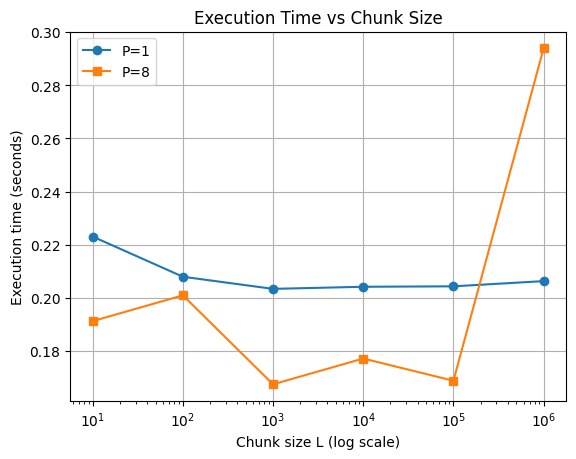

In [16]:
# Test
import multiprocessing as mp
import random
import time
import numpy as np
import matplotlib.pyplot as plt


# ---------- Monte Carlo worker ----------
def mc_chunk(L):
    """Return number of points inside circle for L trials."""
    inside = 0
    for _ in range(L):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            inside += 1
    return inside


# ---------- Experiment ----------
def run_experiment(P):
    TOTAL_TRIALS = int(1e6)

    # chunk sizes: 10,100,...,1e6
    L_values = [10**i for i in range(1, 7)]

    times = []

    for L in L_values:
        N = TOTAL_TRIALS // L  # number of chunks

        start = time.time()

        if P == 1:
            # single-core
            results = list(map(mc_chunk, [L]*N))
        else:
            # multi-core
            with mp.Pool(P) as pool:
                results = pool.map(mc_chunk, [L]*N)

        elapsed = time.time() - start
        times.append(elapsed)

        pi_est = 4 * sum(results) / TOTAL_TRIALS
        print(f"P={P}, L={L}, N={N}, Pi≈{pi_est:.5f}, Time={elapsed:.3f}s")

    return L_values, times


if __name__ == "__main__":
    print("\n--- Single Core (P=1) ---")
    L1, T1 = run_experiment(P=1)

    print("\n--- Multi Core (P=8) ---")
    L8, T8 = run_experiment(P=8)

    # ---------- Plot ----------
    plt.figure()
    plt.semilogx(L1, T1, marker='o', label="P=1")
    plt.semilogx(L8, T8, marker='s', label="P=8")

    plt.xlabel("Chunk size L (log scale)")
    plt.ylabel("Execution time (seconds)")
    plt.title("Execution Time vs Chunk Size")
    plt.legend()
    plt.grid(True)
    plt.show()